In [1]:
from sklearn.metrics import roc_curve, auc
from sklearn import datasets
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from scipy.stats.distributions import chi2
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
#import seaborn as sns
import sys
sys.path.append('..')
np.set_printoptions(suppress=True)

In [2]:
plt.style.use('ggplot')
#plt.rcParams['axes.facecolor']='w'

In [3]:
def likelihood_ratio(lik_reduced, lik_full):
    return(-np.asarray(lik_full)-(-np.asarray(lik_reduced)))

In [5]:
data = pd.read_csv('simulated_data/df_dynamics.csv')

In [7]:
data2 = pd.read_csv('simulated_data/df_flat.csv')

In [8]:
loglik_results = pd.read_csv('output/loglik_results_simulated_data.csv')
#loglik_results = pd.read_csv('output/loglik_results_simulated_data_noise_sd_01.csv')
loglik_results = pd.read_csv('output/loglik_results_simulated_data_noise_sd_03.csv')


In [9]:
loglik_results['model'] = data['model']

In [10]:
#model2 = loglik_results[loglik_results['p_val_21']<0.15]

In [11]:
loglik_results['inferred_label_2'] = 0
loglik_results['true_label_2'] = 0

loglik_results['inferred_label_3'] = 0
loglik_results['true_label_3'] = 0

loglik_results['inferred_label_4'] = 0
loglik_results['true_label_4'] = 0

loglik_results['inferred_label_5'] = 0
loglik_results['true_label_5'] = 0

loglik_results['inferred_label_6'] = 0
loglik_results['true_label_6'] = 0

loglik_results['inferred_label_7'] = 0
loglik_results['true_label_7'] = 0

loglik_results['inferred_label_8'] = 0
loglik_results['true_label_8'] = 0

loglik_results['inferred_label_9'] = 0
loglik_results['true_label_9'] = 0

loglik_results['inferred_label_10'] = 0
loglik_results['true_label_10'] = 0

loglik_results['inferred_label_11'] = 0
loglik_results['true_label_11'] = 0

In [12]:
# Do we need to compute p_val_81?

In [13]:
threshold = 0.15

In [14]:
for i in range(0,2200):
    if(loglik_results.iloc[i]['p_val_21']<threshold and loglik_results.iloc[i]['p_val_31']>threshold and 
       loglik_results.iloc[i]['p_val_82']>threshold and loglik_results.iloc[i]['p_val_42']>threshold and 
       loglik_results.iloc[i]['p_val_43']>threshold):
        loglik_results['inferred_label_2'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==2):  
        loglik_results['true_label_2'].iloc[i] = 1   

/tmp/ipykernel_1457/3392119199.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  loglik_results['inferred_label_2'].iloc[i] = 1
/tmp/ipykernel_1457/3392119199.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [15]:
#loglik_results = loglik_results[loglik_results['model'].isin([1,2])]

In [16]:
#loglik_results[loglik_results['model']==2]['p_val_82']

In [17]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label_2'].to_numpy(), loglik_results['true_label_2'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [18]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [19]:
#sum(loglik_results['true_label'])

### Model 3

In [20]:
loglik_results['p_val_11_3'] = chi2.sf(likelihood_ratio(loglik_results['model_8'], loglik_results['model_11']), 2) #???

In [21]:
loglik_results['p_val_9_11'] = chi2.sf(likelihood_ratio(loglik_results['model_11'], loglik_results['model_9']), 2) #???

In [22]:
loglik_results['p_val_10_5'] = chi2.sf(likelihood_ratio(loglik_results['model_5'], loglik_results['model_10']), 2) #???

In [23]:
loglik_results['p_val_11_4'] = chi2.sf(likelihood_ratio(loglik_results['model_4'], loglik_results['model_11']), 2) #???

In [24]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
      loglik_results.iloc[i]['p_val_63']>threshold and loglik_results.iloc[i]['p_val_9_11']>threshold and 
      loglik_results.iloc[i]['p_val_43']>threshold and loglik_results.iloc[i]['p_val_10_5']>threshold and 
      loglik_results.iloc[i]['p_val_11_4']>threshold):
        loglik_results['inferred_label_3'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==3):  
        loglik_results['true_label_3'].iloc[i] = 1   

/tmp/ipykernel_1457/3782403986.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  loglik_results['inferred_label_3'].iloc[i] = 1
/tmp/ipykernel_1457/3782403986.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [25]:
#loglik_results[loglik_results['model']==1]

In [26]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [27]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [28]:
#sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [29]:
#np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

### Model 4

In [30]:
loglik_results['p_val_43'] = chi2.sf(likelihood_ratio(loglik_results['model_3'], loglik_results['model_4']), 2) #???

In [31]:
loglik_results['p_val_10_4'] = chi2.sf(likelihood_ratio(loglik_results['model_4'], loglik_results['model_10']), 1) #???

In [32]:
loglik_results['p_val_9_10'] = chi2.sf(likelihood_ratio(loglik_results['model_10'], loglik_results['model_9']), 2) #???

In [33]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [34]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_43']<threshold and loglik_results.iloc[i]['p_val_42']<threshold and 
       loglik_results.iloc[i]['p_val_11_4']>threshold and loglik_results.iloc[i]['p_val_10_4']>threshold and 
       loglik_results.iloc[i]['p_val_9_11']>threshold and loglik_results.iloc[i]['p_val_9_10']>threshold and
       loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_82']>threshold):
        loglik_results['inferred_label_4'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==4):  
        loglik_results['true_label_4'].iloc[i] = 1   

/tmp/ipykernel_1457/1396202605.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  loglik_results['inferred_label_4'].iloc[i] = 1
/tmp/ipykernel_1457/1396202605.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [35]:
#loglik_results[loglik_results['model']==4]

In [36]:
# Compute ROC curve and ROC area for each class
#fpr = dict()
#tpr = dict()
#roc_auc = dict()
#for i in range(n_classes):
fpr, tpr, _ = roc_curve(loglik_results['inferred_label_4'].to_numpy(), loglik_results['true_label_4'].to_numpy())
roc_auc = auc(fpr, tpr)

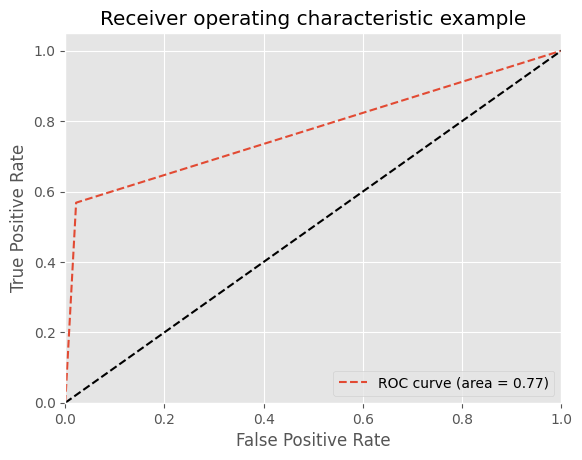

In [37]:
plt.figure()
plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [38]:
sum(loglik_results['true_label_4']-loglik_results['inferred_label_4'])

-78

In [39]:
np.unique(loglik_results[loglik_results['inferred_label_4']==1]['model'])

array([ 2,  4,  6,  7,  9, 10, 11])

In [ ]:
test = loglik_results[loglik_results['inferred_label_4']==1]
test[test['model']==10]

,Unnamed: 0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,...,inferred_label_10,true_label_10,inferred_label_11,true_label_11,p_val_11_3,p_val_9_11,p_val_10_5,p_val_11_4,p_val_10_4,p_val_9_10
1811,1811,71.234477,62.404660,64.430894,54.263943,64.537438,64.817060,62.457751,62.370110,54.104563,...,0,0,0,0,1.600347e-02,1.000000,6.029982e-03,0.921395,1.000000,0.899941
1812,1812,122.029657,72.350443,116.390789,57.573472,117.128111,117.234480,71.321978,72.630791,57.053886,...,0,0,0,0,5.888923e-04,0.703853,8.220118e-14,1.000000,0.401251,1.000000
1818,1818,155.790332,117.452710,130.325488,67.936709,131.066161,133.262991,117.891334,118.087298,69.060233,...,0,0,0,0,1.703560e-11,1.000000,3.022943e-14,1.000000,1.000000,1.000000
1822,1822,134.497703,126.529426,76.824544,52.837652,77.207327,79.815588,126.335662,126.935154,52.888765,...,0,0,0,0,8.659731e-17,0.962779,4.875288e-06,1.000000,0.760412,1.000000
1825,1825,83.835338,62.625220,77.190496,52.494566,77.277960,77.350228,64.787321,63.038954,53.050476,...,0,0,0,0,6.462001e-03,1.000000,4.379278e-06,1.000000,1.000000,1.000000
1829,1829,155.602194,155.466820,73.996093,69.476216,74.612258,77.718692,153.530280,155.520519,68.860605,...,0,0,0,0,2.396069e-19,0.634658,5.258469e-02,1.000000,0.385018,1.000000
1833,1833,213.731813,178.758001,162.823133,65.373663,163.163023,163.243201,179.939610,180.274406,66.707021,...,0,0,0,0,2.201829e-25,0.991681,6.433135e-22,1.000000,1.000000,1.000000
1835,1835,203.870197,203.571616,64.408032,59.037574,65.427984,65.485566,203.760835,203.580481,60.203400,...,0,0,0,0,4.725271e-32,1.000000,6.417474e-02,1.000000,1.000000,1.000000
1838,1838,78.434551,69.379055,73.403192,62.933832,72.441163,72.074717,69.287429,69.770097,62.066368,...,0,0,0,0,3.957733e-02,0.536673,4.489880e-03,1.000000,0.253388,1.000000
1839,1839,130.659243,127.074494,69.463317,58.740530,71.000940,72.544620,127.680451,127.327070,60.170319,...,0,0,0,0,1.352080e-15,1.000000,4.321078e-03,1.000000,1.000000,1.000000


### Model 5

In [ ]:
loglik_results['p_val_56'] = chi2.sf(likelihood_ratio(loglik_results['model_6'], loglik_results['model_5']), 2) #???

In [ ]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [ ]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_53']<threshold and loglik_results.iloc[i]['p_val_56']<threshold):
        loglik_results['inferred_label_5'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==5):  
        loglik_results['true_label_5'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/3884813799.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_5'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/3884813799.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_5'].iloc[i] = 1


In [ ]:
#loglik_results[loglik_results['model']==5]

In [ ]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [ ]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
# sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [ ]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [ ]:
# test = loglik_results[loglik_results['inferred_label']==1]
# test[test['model']==5]

### Model 6

In [ ]:
loglik_results['p_val_96'] = chi2.sf(likelihood_ratio(loglik_results['model_6'], loglik_results['model_9']), 2) #???

In [ ]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_61']<threshold and loglik_results.iloc[i]['p_val_63']<threshold and 
       loglik_results.iloc[i]['p_val_56']>threshold and 
       loglik_results.iloc[i]['p_val_21']>threshold and loglik_results.iloc[i]['p_val_96']>threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_6'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==6):  
        loglik_results['true_label_6'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/3568077552.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_6'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/3568077552.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_6'].iloc[i] = 1


In [ ]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [ ]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
# sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [ ]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [ ]:
# test = loglik_results[loglik_results['inferred_label']==1]
# test[test['model']==6]

In [ ]:
# test = loglik_results[loglik_results['p_val_9_11']<0.15]
# test[test['model']==6]

### Model 7

In [ ]:
loglik_results['p_val_72'] = chi2.sf(likelihood_ratio(loglik_results['model_2'], loglik_results['model_7']), 2) #???

In [ ]:
loglik_results['p_val_87'] = chi2.sf(likelihood_ratio(loglik_results['model_7'], loglik_results['model_8']), 2) #???

In [ ]:
loglik_results['p_val_11_8'] = chi2.sf(likelihood_ratio(loglik_results['model_8'], loglik_results['model_11']), 2) #???

In [ ]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [ ]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_71']<threshold and loglik_results.iloc[i]['p_val_72']<threshold and 
       loglik_results.iloc[i]['p_val_87']>threshold and 
       loglik_results.iloc[i]['p_val_31']>threshold and loglik_results.iloc[i]['p_val_11_8']>threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_7'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==7):  
        loglik_results['true_label_7'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/3557923384.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_7'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/3557923384.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_7'].iloc[i] = 1


In [ ]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [ ]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
# sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [ ]:
np.unique(loglik_results[loglik_results['inferred_label_7']==1]['model'])

array([ 1,  2,  7,  8,  9, 11])

In [ ]:
test = loglik_results[loglik_results['inferred_label_7']==1]
test[test['model']==8]

,Unnamed: 0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,...,p_val_11_3,p_val_9_11,p_val_10_5,p_val_11_4,p_val_10_4,p_val_9_10,p_val_56,p_val_96,p_val_72,p_val_11_8
1400,1400,145.708059,72.525560,145.708062,72.525567,145.708072,145.708071,65.019643,65.105064,65.105070,...,1.000000,0.999998,1.284167e-16,2.447149e-02,1.0,2.447141e-02,1.000000,3.142539e-18,2.344828e-02,1.000000
1401,1401,211.227066,62.779617,211.227074,62.779625,211.227084,211.227080,58.455873,57.929914,57.929940,...,1.000000,1.000000,5.821642e-33,8.849180e-02,1.0,8.849172e-02,1.000000,5.151682e-34,1.151094e-01,1.000000
1402,1402,141.183353,81.990133,141.183264,81.990133,141.183356,141.183356,47.724680,47.817278,47.817316,...,1.000000,1.000000,1.400732e-13,3.797162e-08,1.0,3.797229e-08,1.000000,5.318900e-21,3.625363e-08,1.000000
1403,1403,176.781669,75.349443,176.740647,75.349429,176.781078,176.781676,64.247478,64.396577,64.396574,...,0.999998,1.000000,9.427531e-23,4.184250e-03,1.0,4.184243e-03,0.999701,3.943529e-25,3.883641e-03,0.999998
1407,1407,82.424874,75.559635,82.424877,75.559660,82.424894,82.424891,58.098531,58.723822,58.723843,...,1.000000,1.000000,3.230260e-02,2.208743e-04,1.0,2.208741e-04,1.000000,7.134817e-06,1.615732e-04,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1591,1591,122.755211,62.892598,122.713617,62.892595,122.755226,122.755221,53.222064,53.285591,53.285582,...,0.999992,1.000000,1.002294e-13,8.200915e-03,1.0,8.200937e-03,1.000000,8.219769e-16,7.944567e-03,0.999992
1592,1592,209.715186,77.892448,209.715192,77.892463,209.715197,209.715192,73.663697,73.741081,73.741095,...,1.000000,0.999997,2.371689e-29,1.254710e-01,1.0,1.254704e-01,1.000000,2.975776e-30,1.207087e-01,1.000000
1593,1593,178.154197,69.964262,178.154212,69.964280,178.154222,178.154208,65.790428,65.392612,65.392648,...,1.000000,1.000000,3.212590e-24,1.016909e-01,1.0,1.016904e-01,1.000000,3.266918e-25,1.240691e-01,1.000000
1595,1595,211.821470,67.590330,211.821502,67.590333,211.821477,211.821476,62.839489,62.828225,62.828228,...,1.000000,1.000000,4.792990e-32,9.245321e-02,1.0,9.245290e-02,1.000000,4.431261e-33,9.297541e-02,1.000000


### Model 8

In [ ]:
loglik_results['p_val_9_11'] = chi2.sf(likelihood_ratio(loglik_results['model_11'], loglik_results['model_9']), 2) #???

In [ ]:
loglik_results['p_val_87'] = chi2.sf(likelihood_ratio(loglik_results['model_7'], loglik_results['model_8']), 2) #???

In [ ]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [ ]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_82']<threshold and loglik_results.iloc[i]['p_val_11_8']>threshold and 
      loglik_results.iloc[i]['p_val_9_11']>threshold and loglik_results.iloc[i]['p_val_87']<threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_8'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==8):  
        loglik_results['true_label_8'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/745375270.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_8'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/745375270.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_8'].iloc[i] = 1


In [ ]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [ ]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
# sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [ ]:
# sum(loglik_results['inferred_label'])

In [ ]:
np.unique(loglik_results[loglik_results['inferred_label_8']==1]['model'])

array([8])

In [ ]:
test = loglik_results[loglik_results['inferred_label_8']==1]
test[test['model']==7]

,Unnamed: 0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,...,p_val_11_3,p_val_9_11,p_val_10_5,p_val_11_4,p_val_10_4,p_val_9_10,p_val_56,p_val_96,p_val_72,p_val_11_8


### Model 9

In [ ]:
loglik_results['p_val_96'] = chi2.sf(likelihood_ratio(loglik_results['model_6'], loglik_results['model_9']), 2) #???

In [ ]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [ ]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_9_11']<threshold and loglik_results.iloc[i]['p_val_9_10']<threshold and 
        loglik_results.iloc[i]['p_val_97']<threshold and loglik_results.iloc[i]['p_val_96']<threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_9'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==9):  
        loglik_results['true_label_9'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/2339881876.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_9'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/2339881876.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_9'].iloc[i] = 1


In [ ]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [ ]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [ ]:
# sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [ ]:
# sum(loglik_results['inferred_label'])

### Model 10

In [ ]:
loglik_results['p_val_10_5'] = chi2.sf(likelihood_ratio(loglik_results['model_5'], loglik_results['model_10']), 2) #???

In [ ]:
loglik_results['p_val_10_3'] = chi2.sf(likelihood_ratio(loglik_results['model_3'], loglik_results['model_10']), 2) #???

In [ ]:
loglik_results['p_val_10_1'] = chi2.sf(likelihood_ratio(loglik_results['model_1'], loglik_results['model_10']), 2) #???

In [ ]:
loglik_results['p_val_10_2'] = chi2.sf(likelihood_ratio(loglik_results['model_2'], loglik_results['model_10']), 2) #???

In [ ]:
loglik_results['p_val_10_4'] = chi2.sf(likelihood_ratio(loglik_results['model_4'], loglik_results['model_10']), 2) #???

In [ ]:
loglik_results['p_val_11_4'] = chi2.sf(likelihood_ratio(loglik_results['model_4'], loglik_results['model_11']), 2) #???

In [ ]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [ ]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_10_4']<threshold and loglik_results.iloc[i]['p_val_10_5']<threshold and 
       loglik_results.iloc[i]['p_val_9_10']>threshold and loglik_results.iloc[i]['p_val_11_4']>threshold and
      loglik_results.iloc[i]['p_val_42']<threshold and loglik_results.iloc[i]['p_val_43']<threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_10'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==10):  
        loglik_results['true_label_10'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/3950900615.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_10'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/3950900615.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_10'].iloc[i] = 1


In [ ]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [ ]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [ ]:
# test = loglik_results[loglik_results['inferred_label']==1]
# test[test['model']==4]

### Model 11

In [ ]:
loglik_results['p_val_11_8'] = chi2.sf(likelihood_ratio(loglik_results['model_8'], loglik_results['model_11']), 2) #???

In [ ]:
loglik_results['p_val_11_4'] = chi2.sf(likelihood_ratio(loglik_results['model_4'], loglik_results['model_11']), 2) #???

In [ ]:
loglik_results['p_val_9_11'] = chi2.sf(likelihood_ratio(loglik_results['model_11'], loglik_results['model_9']), 2) #???

In [ ]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [ ]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_11_8']<threshold and loglik_results.iloc[i]['p_val_11_4']<threshold and 
      loglik_results.iloc[i]['p_val_9_11']>threshold and loglik_results.iloc[i]['p_val_43']<threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_11'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==11):  
        loglik_results['true_label_11'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/814035546.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_11'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_62181/814035546.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_11'].iloc[i] = 1


In [ ]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [ ]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [ ]:
# test = loglik_results[loglik_results['inferred_label']==1]
# test[test['model']==3]

In [ ]:
fpr_2, tpr_2, _ = roc_curve(loglik_results['inferred_label_2'].to_numpy(), loglik_results['true_label_2'].to_numpy())
roc_auc_2 = auc(fpr_2, tpr_2)

fpr_3, tpr_3, _ = roc_curve(loglik_results['inferred_label_3'].to_numpy(), loglik_results['true_label_3'].to_numpy())
roc_auc_3 = auc(fpr_3, tpr_3)

fpr_4, tpr_4, _ = roc_curve(loglik_results['inferred_label_4'].to_numpy(), loglik_results['true_label_4'].to_numpy())
roc_auc_4 = auc(fpr_4, tpr_4)

fpr_5, tpr_5, _ = roc_curve(loglik_results['inferred_label_5'].to_numpy(), loglik_results['true_label_5'].to_numpy())
roc_auc_5 = auc(fpr_5, tpr_5)

fpr_6, tpr_6, _ = roc_curve(loglik_results['inferred_label_6'].to_numpy(), loglik_results['true_label_6'].to_numpy())
roc_auc_6 = auc(fpr_6, tpr_6)

fpr_7, tpr_7, _ = roc_curve(loglik_results['inferred_label_7'].to_numpy(), loglik_results['true_label_7'].to_numpy())
roc_auc_7 = auc(fpr_7, tpr_7)

fpr_8, tpr_8, _ = roc_curve(loglik_results['inferred_label_8'].to_numpy(), loglik_results['true_label_8'].to_numpy())
roc_auc_8 = auc(fpr_8, tpr_8)

fpr_9, tpr_9, _ = roc_curve(loglik_results['inferred_label_9'].to_numpy(), loglik_results['true_label_9'].to_numpy())
roc_auc_9 = auc(fpr_9, tpr_9)

fpr_10, tpr_10, _ = roc_curve(loglik_results['inferred_label_10'].to_numpy(), loglik_results['true_label_10'].to_numpy())
roc_auc_10 = auc(fpr_10, tpr_10)

fpr_11, tpr_11, _ = roc_curve(loglik_results['inferred_label_11'].to_numpy(), loglik_results['true_label_11'].to_numpy())
roc_auc_11 = auc(fpr_11, tpr_11)

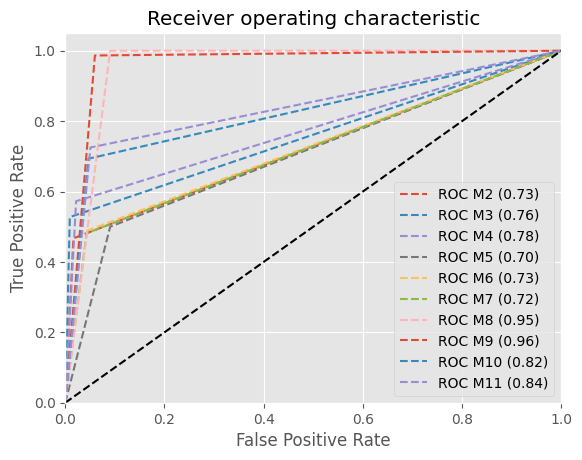

In [ ]:
plt.figure()
plt.plot(fpr_2, tpr_2, '--', label='ROC M2 (%0.2f)' % roc_auc_2)
plt.plot(fpr_3, tpr_3, '--', label='ROC M3 (%0.2f)' % roc_auc_3)
plt.plot(fpr_4, tpr_4, '--', label='ROC M4 (%0.2f)' % roc_auc_4)
plt.plot(fpr_5, tpr_5, '--', label='ROC M5 (%0.2f)' % roc_auc_5)
plt.plot(fpr_6, tpr_6, '--', label='ROC M6 (%0.2f)' % roc_auc_6)
plt.plot(fpr_7, tpr_7, '--', label='ROC M7 (%0.2f)' % roc_auc_7)
plt.plot(fpr_8, tpr_8, '--', label='ROC M8 (%0.2f)' % roc_auc_8)
plt.plot(fpr_9, tpr_9, '--', label='ROC M9 (%0.2f)' % roc_auc_9)
plt.plot(fpr_10, tpr_10, '--', label='ROC M10 (%0.2f)' % roc_auc_10)
plt.plot(fpr_11, tpr_11, '--', label='ROC M11 (%0.2f)' % roc_auc_11)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('ROC_dynamic_data_03.png', dpi=300)
plt.show()